# 🔎 TP : explorer un jeu industriel avec Pandas, Polars et les corrélations

**Durée indicative : 3 h — Niveau : initiation/intermédiaire.**

## Objectifs observables

À la fin de ce notebook, vous saurez :

1. distinguer type physique, type logique et rôle analytique ;
2. auditer une table avec Pandas et reproduire une agrégation avec Polars ;
3. choisir un graphique selon une question descriptive ;
4. construire et interpréter des matrices de Pearson et Spearman ;
5. étudier une cible binaire avec variables numériques et catégorielles ;
6. sélectionner des variables sans identifiant, proxy injustifié ni fuite ;
7. valider cette sélection sur l'entraînement avant d'ouvrir le test.

> Le jeu est synthétique et généré localement. Nous connaissons son mécanisme, ce qui permet de vérifier si l'EDA retrouve les signaux injectés. Une association prédictive n'est pas une preuve causale.

## 1. Préparer l'environnement

Pandas sert à l'exploration et s'intègre largement à l'écosystème Python. Polars propose un moteur colonnaire, des expressions et une API lazy. Le notebook reste exécutable sans Polars, mais son installation est prévue par `requirements.txt`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

try:
    import polars as pl
except ModuleNotFoundError:
    pl = None

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110})
BLUE, GOLD, ORANGE, INK = "#3973AC", "#D9A441", "#D97745", "#263238"
print("Pandas :", pd.__version__)
print("Polars :", pl.__version__ if pl is not None else "non installé (section ignorée)")

Pandas : 3.0.5
Polars : 1.44.1


## 2. Construire un jeu de demandes de crédit

Chaque ligne représente **une demande**, au moment où elle est déposée. La cible `defaut_paiement` vaut 1 si un défaut est observé dans l'horizon simulé.

Le jeu contient volontairement : nombres continus et discrets, booléen, date, catégories, texte libre, structure imbriquée, valeurs manquantes, valeurs aberrantes, identifiant, variable aléatoire et cible binaire.

In [2]:
rng = np.random.default_rng(42)
n = 1_500

revenu_propre = np.exp(rng.normal(np.log(45_000), 0.38, n))
montant_propre = rng.gamma(shape=2.0, scale=9_000, size=n) + 3_000
score_credit = np.clip(rng.normal(650, 70, n), 300, 850)
incidents_12m = rng.poisson(0.7, n)
anciennete_client_mois = rng.integers(1, 181, n)
canal = rng.choice(["agence", "web", "telephone"], n, p=[0.35, 0.50, 0.15])
region = rng.choice(["Nord", "Sud", "Est", "Ouest", "Centre"], n)
niveau_education = rng.choice(
    ["Secondaire", "Licence", "Master", "Doctorat"],
    n,
    p=[0.30, 0.40, 0.25, 0.05],
)

# La cible synthétique dépend de quatre signaux et d'un faible effet de canal.
ratio_latent = montant_propre / revenu_propre
logit = (
    -2.6
    + 1.25 * ratio_latent
    + 0.65 * incidents_12m
    - 0.008 * (score_credit - 600)
    - 0.006 * np.minimum(anciennete_client_mois, 120)
    + 0.25 * (canal == "telephone")
)
probabilite_defaut = 1 / (1 + np.exp(-np.clip(logit, -30, 30)))
defaut_paiement = (rng.random(n) < probabilite_defaut).astype(int)

revenu_observe = revenu_propre.copy()
montant_observe = montant_propre.copy()
revenu_observe[0], revenu_observe[1] = 1_500_000, -5_000
montant_observe[2] = 450_000
revenu_observe[rng.random(n) < 0.07] = np.nan
canal_observe = canal.astype(object)
canal_observe[rng.random(n) < 0.03] = None

date_demande = pd.Timestamp("2024-01-01") + pd.to_timedelta(
    rng.integers(0, 540, n), unit="D"
)

df = pd.DataFrame({
    "id_client": [f"CLI-{i:06d}" for i in range(n)],
    "date_demande": date_demande,
    "revenu_annuel": revenu_observe,
    "montant_credit": montant_observe,
    "score_credit": score_credit.round(0),
    "incidents_12m": incidents_12m,
    "anciennete_client_mois": anciennete_client_mois,
    "canal": canal_observe,
    "region": region,
    "niveau_education": niveau_education,
    "consentement_marketing": rng.random(n) < 0.62,
    "couleur_interface": rng.choice(["bleu", "sable", "ardoise"], n),
    "bruit_aleatoire": rng.normal(size=n),
    "commentaire": rng.choice(
        ["dossier complet", "pièce à vérifier", "client rappelé", ""], n
    ),
    "metadata_source": [
        {"application": "portail-credit", "version": int(v)}
        for v in rng.integers(1, 4, n)
    ],
    "defaut_paiement": defaut_paiement,
})

assert df["id_client"].is_unique
assert set(df["defaut_paiement"].unique()) == {0, 1}
print(f"Jeu créé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Taux de défaut : {df['defaut_paiement'].mean():.1%}")
display(df.head(3))

Jeu créé : 1500 lignes × 16 colonnes
Taux de défaut : 11.7%


,id_client,date_demande,revenu_annuel,montant_credit,score_credit,incidents_12m,anciennete_client_mois,canal,region,niveau_education,consentement_marketing,couleur_interface,bruit_aleatoire,commentaire,metadata_source,defaut_paiement
0,CLI-000000,2024-07-30,1.500000e+06,12335.427234,705.0,2,4,web,Centre,Licence,True,ardoise,0.229485,,"{'application': 'portail-credit', 'version': 1}",0
1,CLI-000001,2024-02-12,-5.000000e+03,39265.677819,576.0,0,96,telephone,Sud,Doctorat,True,sable,1.567023,,"{'application': 'portail-credit', 'version': 3}",0
2,CLI-000002,2024-01-18,5.984955e+04,450000.000000,672.0,0,107,web,Sud,Secondaire,False,ardoise,-1.003876,pièce à vérifier,"{'application': 'portail-credit', 'version': 2}",0


### 2.1 Documenter le rôle avant de regarder les scores

Le `dtype` ne dit pas si une colonne est une feature licite. Le tableau suivant constitue un mini dictionnaire de données.

In [3]:
roles = {
    "id_client": ("identifiant", "nominal", "clé, jamais feature"),
    "date_demande": ("temps", "temporel", "split/contrôle de stabilité"),
    "revenu_annuel": ("feature", "ratio continu", "imputation requise"),
    "montant_credit": ("feature", "ratio continu", "contrôler les outliers"),
    "score_credit": ("feature", "intervalle", "provenance à documenter"),
    "incidents_12m": ("feature", "compte discret", "fenêtre antérieure"),
    "anciennete_client_mois": ("feature", "ratio discret", "disponible à la demande"),
    "canal": ("feature candidate", "nominal", "manquants présents"),
    "region": ("audit", "nominal", "proxy potentiel, usage à justifier"),
    "niveau_education": ("audit", "ordinal", "sensibilité/proxy à examiner"),
    "consentement_marketing": ("gouvernance", "booléen", "sans lien avec le risque"),
    "couleur_interface": ("bruit", "nominal", "aucune hypothèse métier"),
    "bruit_aleatoire": ("bruit", "continu", "contrôle négatif"),
    "commentaire": ("texte", "non structuré", "pipeline NLP séparé"),
    "metadata_source": ("métadonnée", "structure imbriquée", "traçabilité"),
    "defaut_paiement": ("cible", "binaire", "y uniquement"),
}

dictionnaire = pd.DataFrame.from_dict(
    roles, orient="index", columns=["rôle", "type logique", "décision initiale"]
)
dictionnaire["dtype Pandas"] = df.dtypes.astype(str)
display(dictionnaire)

,rôle,type logique,décision initiale,dtype Pandas
id_client,identifiant,nominal,"clé, jamais feature",str
date_demande,temps,temporel,split/contrôle de stabilité,datetime64[us]
revenu_annuel,feature,ratio continu,imputation requise,float64
montant_credit,feature,ratio continu,contrôler les outliers,float64
score_credit,feature,intervalle,provenance à documenter,float64
incidents_12m,feature,compte discret,fenêtre antérieure,int64
anciennete_client_mois,feature,ratio discret,disponible à la demande,int64
canal,feature candidate,nominal,manquants présents,str
region,audit,nominal,"proxy potentiel, usage à justifier",str
niveau_education,audit,ordinal,sensibilité/proxy à examiner,str


## 3. Premier audit avec Pandas

L'audit combine forme, types, manquants, cardinalité et exemples. `describe()` complète ce profil, mais ne remplace pas la connaissance métier.

In [4]:
def cardinalite_sure(series):
    try:
        return series.nunique(dropna=True)
    except TypeError:
        return series.map(repr).nunique(dropna=True)

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "manquants_n": df.isna().sum(),
    "manquants_pct": (100 * df.isna().mean()).round(2),
    "cardinalite": df.apply(cardinalite_sure),
    "exemple": [next((v for v in df[c] if not pd.isna(v)), None) for c in df.columns],
})

print("Forme :", df.shape)
print("Doublons complets hors structure imbriquée :", df.drop(columns="metadata_source").duplicated().sum())
print("Identifiants dupliqués :", df["id_client"].duplicated().sum())
display(audit)
display(df.describe(include="number").T.round(2))

Forme : (1500, 16)
Doublons complets hors structure imbriquée : 0
Identifiants dupliqués : 0


,dtype,manquants_n,manquants_pct,cardinalite,exemple
id_client,str,0,0.00,1500,CLI-000000
date_demande,datetime64[us],0,0.00,496,2024-07-30 00:00:00
revenu_annuel,float64,112,7.47,1388,1500000.0
montant_credit,float64,0,0.00,1500,12335.427234
score_credit,float64,0,0.00,324,705.0
incidents_12m,int64,0,0.00,6,2
anciennete_client_mois,int64,0,0.00,179,4
canal,str,52,3.47,3,web
region,str,0,0.00,5,Centre
niveau_education,str,0,0.00,4,Licence


,count,mean,std,min,25%,50%,75%,max
revenu_annuel,1388.0,49011.14,43151.51,-5000.00,34826.41,45170.75,57219.73,1500000.00
montant_credit,1500.0,21404.56,17167.61,3267.18,11631.81,18347.91,26749.85,450000.00
score_credit,1500.0,650.81,71.23,343.00,603.00,652.00,698.00,850.00
incidents_12m,1500.0,0.71,0.85,0.00,0.00,1.00,1.00,5.00
anciennete_client_mois,1500.0,89.63,52.59,1.00,43.75,89.00,135.00,180.00
bruit_aleatoire,1500.0,-0.01,0.99,-3.19,-0.69,-0.02,0.66,3.01
defaut_paiement,1500.0,0.12,0.32,0.00,0.00,0.00,0.00,1.00


## 4. Reproduire une agrégation avec Polars

L'exemple utilise des expressions et une requête lazy. `collect_schema()` inspecte le schéma ; `collect()` déclenche l'exécution. La colonne imbriquée est exclue de cette conversion d'initiation.

In [5]:
resume_pandas = (
    df.groupby("canal", dropna=False)
      .agg(n=("id_client", "size"), taux_defaut=("defaut_paiement", "mean"))
      .sort_values("taux_defaut", ascending=False)
)
print("Agrégation Pandas")
display(resume_pandas.round(3))

if pl is not None:
    colonnes_simples = [c for c in df.columns if c != "metadata_source"]
    donnees_polars = {
        c: [None if pd.isna(value) else value for value in df[c].tolist()]
        for c in colonnes_simples
    }
    df_polars = pl.from_dict(donnees_polars)
    requete = (
        df_polars.lazy()
        .group_by("canal")
        .agg(
            pl.len().alias("n"),
            pl.col("defaut_paiement").mean().alias("taux_defaut"),
        )
        .sort("taux_defaut", descending=True)
    )
    print("Schéma Polars :", requete.collect_schema())
    print(requete.collect())
else:
    print("Installez les dépendances du cours pour exécuter la variante Polars.")

Agrégation Pandas


,n,taux_defaut
canal,,
NaN,52,0.173
web,732,0.122
telephone,209,0.115
agence,507,0.105


Schéma Polars : Schema({'canal': String, 'n': UInt32, 'taux_defaut': Float64})
shape: (4, 3)
┌───────────┬─────┬─────────────┐
│ canal     ┆ n   ┆ taux_defaut │
│ ---       ┆ --- ┆ ---         │
│ str       ┆ u32 ┆ f64         │
╞═══════════╪═════╪═════════════╡
│ null      ┆ 52  ┆ 0.173077    │
│ web       ┆ 732 ┆ 0.121585    │
│ telephone ┆ 209 ┆ 0.114833    │
│ agence    ┆ 507 ┆ 0.104536    │
└───────────┴─────┴─────────────┘


## 5. Visualiser qualité, cible et distributions

Chaque figure répond à une question : où manque-t-il des données ? La cible est-elle rare ? Les nombres présentent-ils asymétrie ou valeurs extrêmes ?

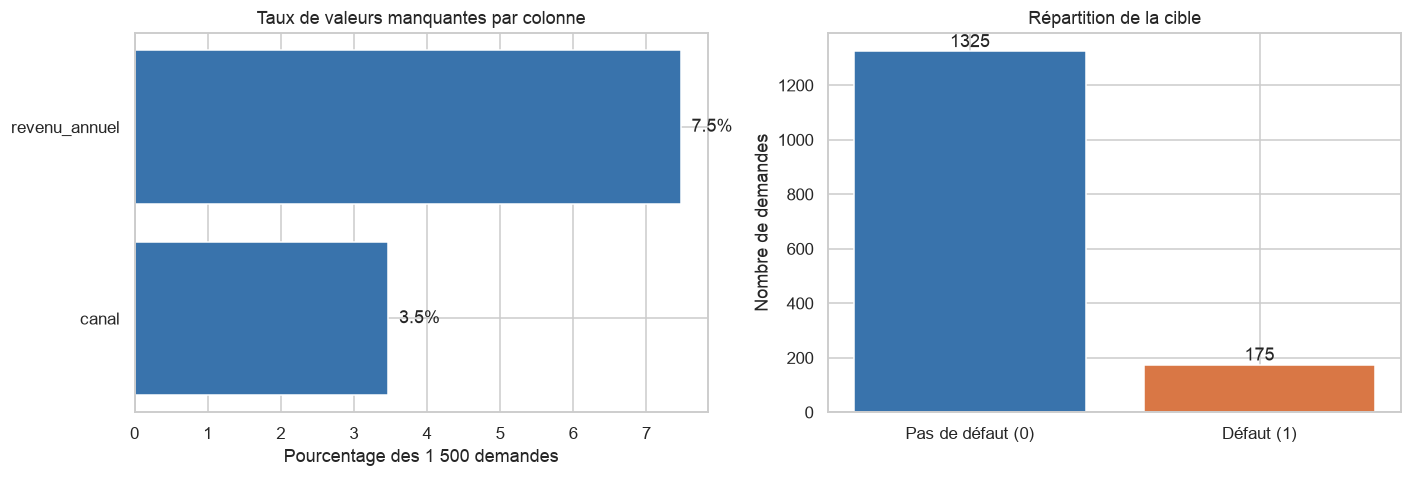

In [6]:
missing_pct = (100 * df.isna().mean()).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]
target_counts = df["defaut_paiement"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(missing_pct.index, missing_pct.values, color=BLUE)
axes[0].set_title("Taux de valeurs manquantes par colonne")
axes[0].set_xlabel("Pourcentage des 1 500 demandes")
for i, value in enumerate(missing_pct.values):
    axes[0].text(value + 0.15, i, f"{value:.1f}%", va="center")

axes[1].bar(["Pas de défaut (0)", "Défaut (1)"], target_counts.values, color=[BLUE, ORANGE])
axes[1].set_title("Répartition de la cible")
axes[1].set_ylabel("Nombre de demandes")
for i, value in enumerate(target_counts.values):
    axes[1].text(i, value + 15, str(value), ha="center")
plt.tight_layout()
plt.show()

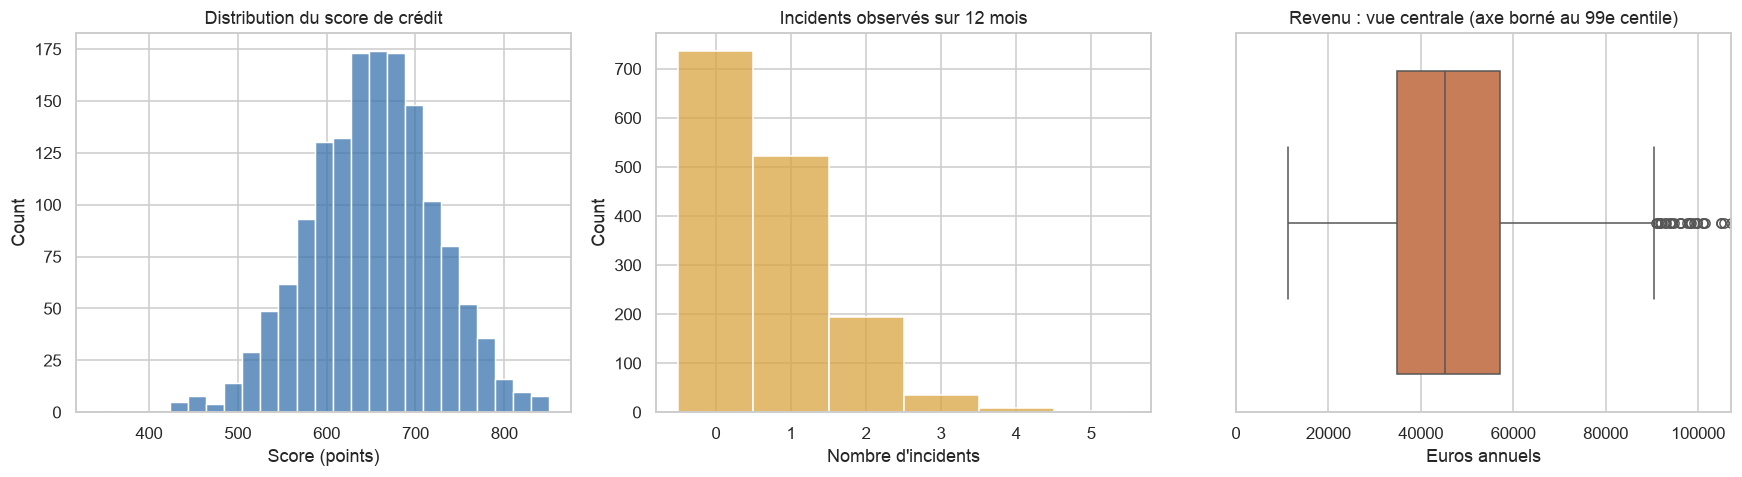

Extrêmes à examiner :


,id_client,revenu_annuel
1,CLI-000001,-5000.000000
949,CLI-000949,11248.846794


,id_client,revenu_annuel
0,CLI-000000,1.500000e+06
139,CLI-000139,1.361736e+05


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df["score_credit"], bins=25, color=BLUE, ax=axes[0])
axes[0].set_title("Distribution du score de crédit")
axes[0].set_xlabel("Score (points)")

sns.histplot(df["incidents_12m"], discrete=True, color=GOLD, ax=axes[1])
axes[1].set_title("Incidents observés sur 12 mois")
axes[1].set_xlabel("Nombre d'incidents")

sns.boxplot(x=df["revenu_annuel"], color=ORANGE, ax=axes[2])
axes[2].set_title("Revenu : vue centrale (axe borné au 99e centile)")
axes[2].set_xlim(0, df["revenu_annuel"].quantile(0.99))
axes[2].set_xlabel("Euros annuels")
plt.tight_layout()
plt.show()

print("Extrêmes à examiner :")
display(df.nsmallest(2, "revenu_annuel")[["id_client", "revenu_annuel"]])
display(df.nlargest(2, "revenu_annuel")[["id_client", "revenu_annuel"]])

## 6. Séparer avant toute exploration utilisant la cible

Les distributions d'entrée servent au contrôle de qualité. À partir de maintenant, toute sélection liée à `defaut_paiement` utilise seulement le train. Le jeu synthétique est stationnaire ; un cas réel destiné au futur demanderait un split temporel.

In [8]:
X = df.drop(columns="defaut_paiement")
y = df["defaut_paiement"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

def ajouter_ratio(frame):
    resultat = frame.copy()
    revenu_valide = resultat["revenu_annuel"].where(resultat["revenu_annuel"] > 0)
    resultat["ratio_endettement"] = resultat["montant_credit"] / revenu_valide
    return resultat

X_train = ajouter_ratio(X_train)
X_test = ajouter_ratio(X_test)
train_eda = X_train.copy()
train_eda["defaut_paiement"] = y_train

assert X_train.index.intersection(X_test.index).empty
assert not np.isinf(X_train["ratio_endettement"].dropna()).any()
print("Train :", X_train.shape, f"— défaut {y_train.mean():.1%}")
print("Test  :", X_test.shape, f"— défaut {y_test.mean():.1%}")

Train : (1200, 16) — défaut 11.7%
Test  : (300, 16) — défaut 11.7%


## 7. Matrices de corrélation Pearson et Spearman

Pearson recherche une relation linéaire ; Spearman une relation monotone entre les rangs. Avec la cible 0/1, Pearson donne la corrélation point-bisériale. Les deux matrices utilisent exclusivement l'entraînement.

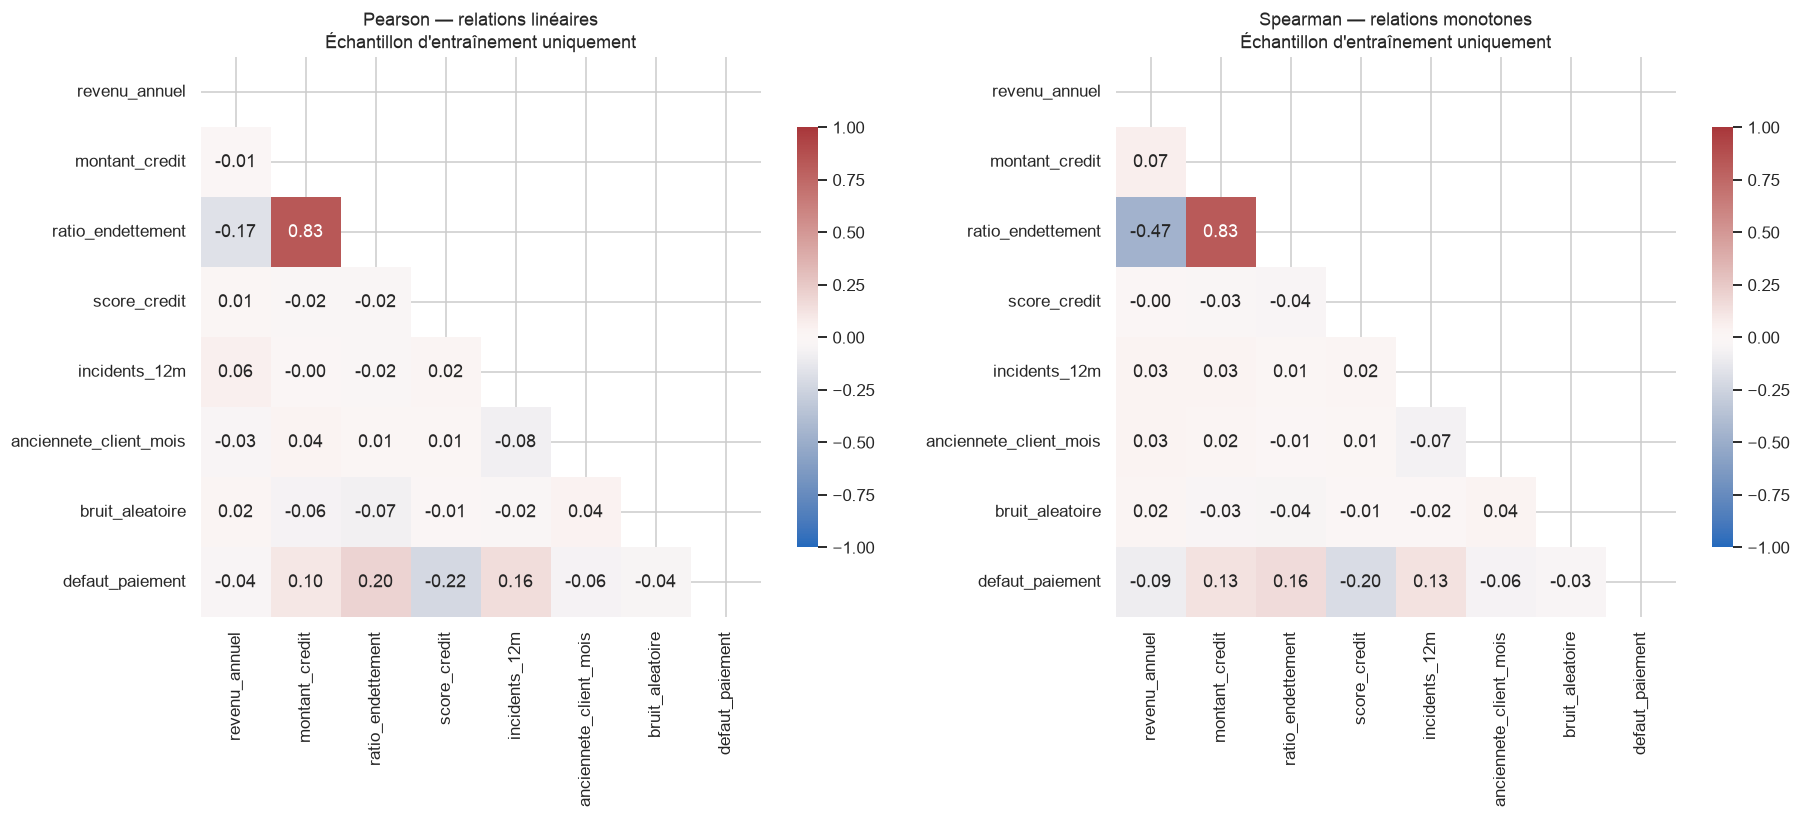

,Pearson,Spearman
score_credit,-0.223,-0.200
ratio_endettement,0.200,0.157
incidents_12m,0.156,0.132
montant_credit,0.102,0.132
anciennete_client_mois,-0.061,-0.060
bruit_aleatoire,-0.042,-0.033
revenu_annuel,-0.037,-0.094


In [9]:
numeric_for_corr = [
    "revenu_annuel", "montant_credit", "ratio_endettement",
    "score_credit", "incidents_12m", "anciennete_client_mois",
    "bruit_aleatoire", "defaut_paiement",
]
pearson = train_eda[numeric_for_corr].corr(method="pearson", min_periods=100)
spearman = train_eda[numeric_for_corr].corr(method="spearman", min_periods=100)
mask = np.triu(np.ones_like(pearson, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, matrix, title in [
    (axes[0], pearson, "Pearson — relations linéaires"),
    (axes[1], spearman, "Spearman — relations monotones"),
]:
    sns.heatmap(
        matrix, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", square=True, cbar_kws={"shrink": 0.75}, ax=ax,
    )
    ax.set_title(title + "\nÉchantillon d'entraînement uniquement")
plt.tight_layout()
plt.show()

association_target = pd.concat(
    [pearson["defaut_paiement"], spearman["defaut_paiement"]], axis=1
).drop(index="defaut_paiement")
association_target.columns = ["Pearson", "Spearman"]
display(association_target.reindex(association_target.Pearson.abs().sort_values(ascending=False).index).round(3))

### 7.1 Une corrélation proche de zéro peut cacher une relation

Cette démonstration fabrique une relation en U. Pearson et Spearman sont proches de zéro car la relation n'est pas monotone. Le graphique reste indispensable.

Pearson : -0.052
Spearman: -0.088


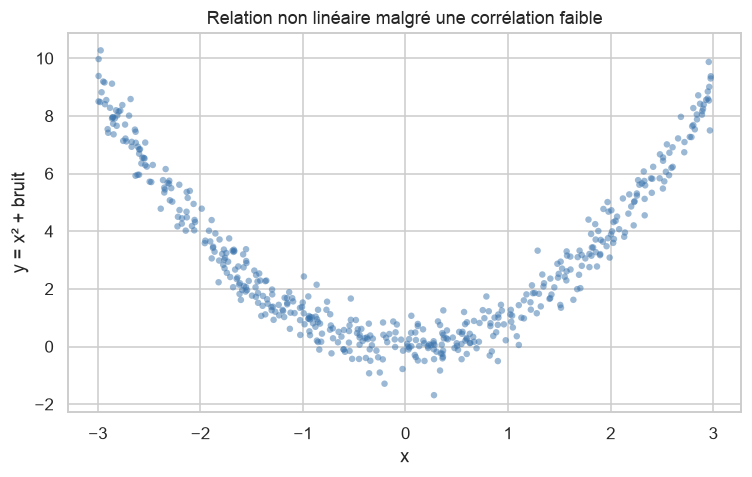

In [10]:
x_curve = rng.uniform(-3, 3, 500)
y_curve = x_curve ** 2 + rng.normal(0, 0.5, 500)
demo_curve = pd.DataFrame({"x": x_curve, "y": y_curve})

print("Pearson :", round(demo_curve.corr(method="pearson").loc["x", "y"], 3))
print("Spearman:", round(demo_curve.corr(method="spearman").loc["x", "y"], 3))
plt.figure(figsize=(7, 4.5))
plt.scatter(x_curve, y_curve, s=18, alpha=0.5, color=BLUE, edgecolors="none")
plt.title("Relation non linéaire malgré une corrélation faible")
plt.xlabel("x")
plt.ylabel("y = x² + bruit")
plt.tight_layout()
plt.show()

## 8. Variables catégorielles et cible

Une matrice de Pearson n'analyse pas correctement des catégories nominales. Nous affichons le taux de défaut par modalité et calculons le V de Cramér. Une association observée ne justifie pas automatiquement l'usage d'une variable sensible ou proxy.

,V de Cramér
niveau_education,0.057
canal,0.040
couleur_interface,0.034
region,0.019


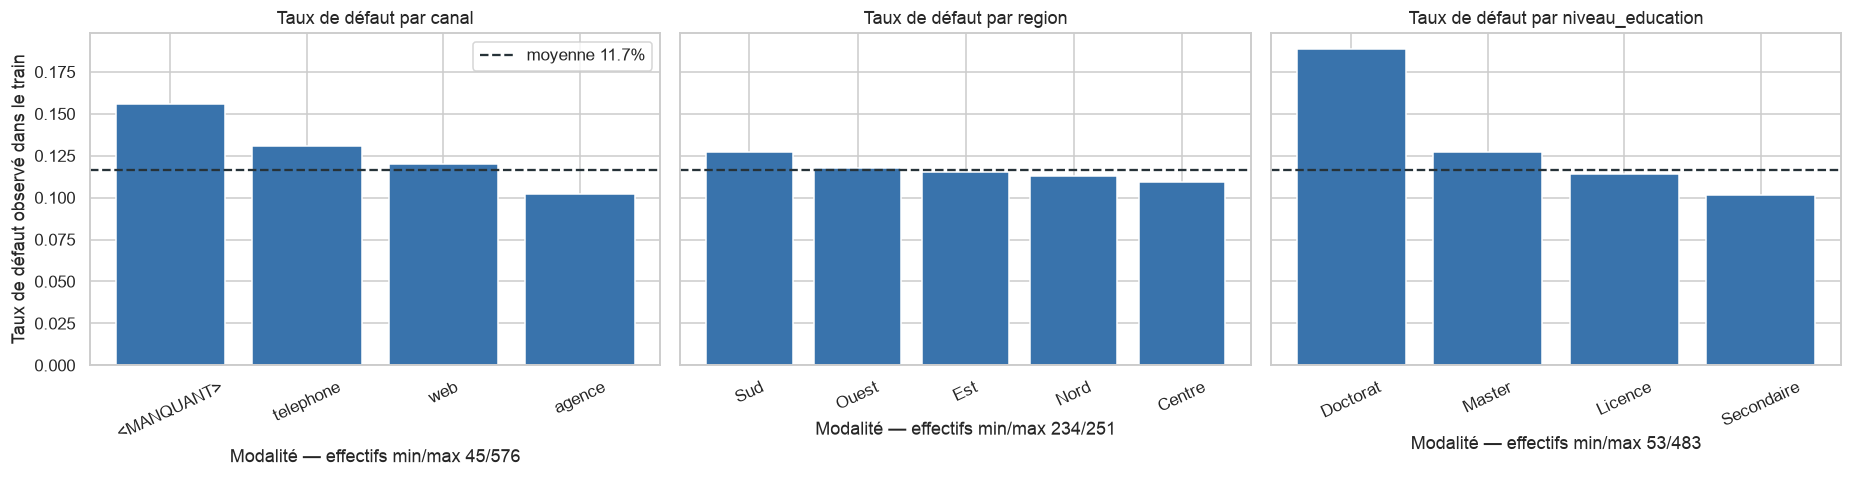

In [11]:
def cramers_v(feature, target):
    table = pd.crosstab(feature.fillna("<MANQUANT>"), target)
    chi2 = chi2_contingency(table, correction=False)[0]
    n_obs = table.to_numpy().sum()
    denominator = min(table.shape[0] - 1, table.shape[1] - 1)
    return np.sqrt((chi2 / n_obs) / denominator) if denominator > 0 else 0.0

categorical_candidates = ["canal", "region", "niveau_education", "couleur_interface"]
cramer = pd.Series(
    {column: cramers_v(X_train[column], y_train) for column in categorical_candidates},
    name="V de Cramér",
).sort_values(ascending=False)
display(cramer.round(3).to_frame())

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
baseline = y_train.mean()
for ax, column in zip(axes, ["canal", "region", "niveau_education"]):
    rates = train_eda.groupby(column, dropna=False)["defaut_paiement"].agg(["mean", "size"])
    rates = rates.sort_values("mean", ascending=False)
    labels = [str(value) if pd.notna(value) else "<MANQUANT>" for value in rates.index]
    ax.bar(labels, rates["mean"], color=BLUE)
    ax.axhline(baseline, color=INK, linestyle="--", label=f"moyenne {baseline:.1%}")
    ax.set_title(f"Taux de défaut par {column}")
    ax.set_xlabel(f"Modalité — effectifs min/max {rates['size'].min()}/{rates['size'].max()}")
    ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Taux de défaut observé dans le train")
axes[0].legend()
plt.tight_layout()
plt.show()

## 9. Information mutuelle et sélection raisonnée

L'information mutuelle peut détecter certaines relations non linéaires. Elle reste un score univarié dépendant de l'échantillon. Le prétraitement est ajusté sur le train uniquement.

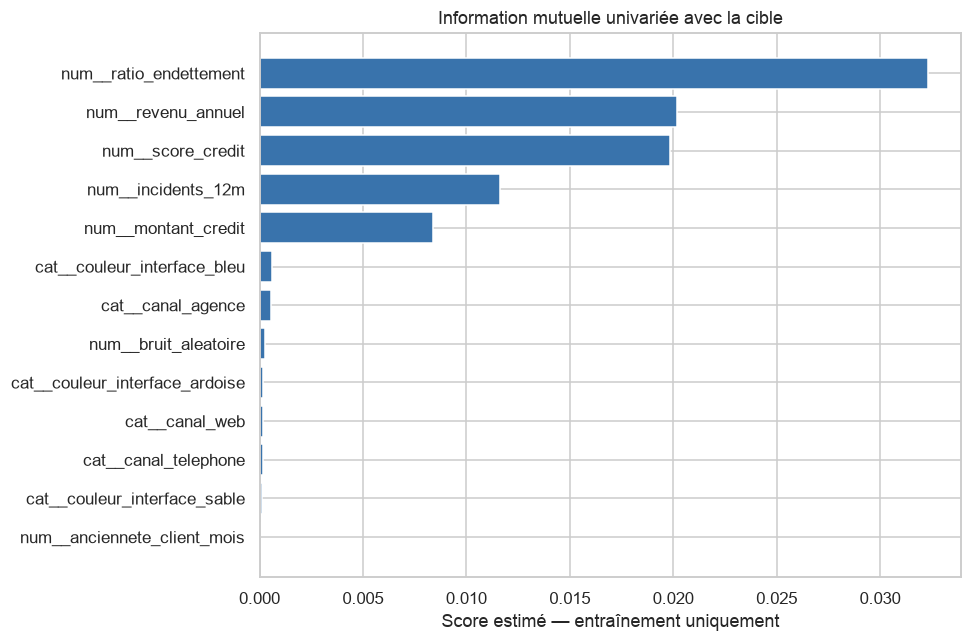

,information_mutuelle
num__ratio_endettement,0.0323
num__revenu_annuel,0.0202
num__score_credit,0.0199
num__incidents_12m,0.0116
num__montant_credit,0.0084
cat__couleur_interface_bleu,0.0006
cat__canal_agence,0.0005
num__bruit_aleatoire,0.0003
cat__couleur_interface_ardoise,0.0002
cat__canal_web,0.0002


In [12]:
numeric_candidates = [
    "revenu_annuel", "montant_credit", "ratio_endettement", "score_credit",
    "incidents_12m", "anciennete_client_mois", "bruit_aleatoire",
]
categorical_candidates = ["canal", "couleur_interface"]

mi_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]), numeric_candidates),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_candidates),
])

X_mi = mi_preprocessor.fit_transform(X_train)
mi_names = mi_preprocessor.get_feature_names_out()
discrete_mask = np.array([name.startswith("cat__") for name in mi_names])
mi_scores = mutual_info_classif(
    X_mi, y_train, discrete_features=discrete_mask, random_state=42
)
mi_table = pd.Series(mi_scores, index=mi_names, name="information_mutuelle").sort_values()

plt.figure(figsize=(9, 6))
plt.barh(mi_table.index, mi_table.values, color=BLUE)
plt.title("Information mutuelle univariée avec la cible")
plt.xlabel("Score estimé — entraînement uniquement")
plt.tight_layout()
plt.show()
display(mi_table.sort_values(ascending=False).round(4).to_frame())

### 9.1 Décision de sélection

Nous excluons l'identifiant, le texte et les métadonnées de cette baseline tabulaire. `region` et `niveau_education` restent disponibles pour l'audit mais leur emploi comme features demanderait une justification. `couleur_interface` et `bruit_aleatoire` servent de contrôles négatifs.

Nous comparons sur les **mêmes plis du train** un jeu métier sélectionné et le même jeu enrichi de deux bruits. Le test reste fermé.

In [13]:
selected_numeric = [
    "revenu_annuel", "montant_credit", "ratio_endettement",
    "score_credit", "incidents_12m", "anciennete_client_mois",
]
selected_categorical = ["canal"]

selection_decisions = pd.DataFrame([
    ("id_client", "exclure", "identifiant arbitraire"),
    ("date_demande", "audit/split", "pas de signal temporel injecté ici"),
    ("revenu, montant, ratio, score, incidents, ancienneté", "conserver", "disponibles et plausibles"),
    ("canal", "conserver provisoirement", "faible effet injecté, manquants gérés"),
    ("region, niveau_education", "audit uniquement", "proxies potentiels à justifier"),
    ("consentement_marketing", "exclure", "finalité différente"),
    ("couleur_interface, bruit_aleatoire", "contrôles négatifs", "aucune hypothèse métier"),
    ("commentaire", "pipeline séparé", "texte non structuré"),
    ("metadata_source", "exclure", "traçabilité, pas feature"),
], columns=["variable", "décision", "raison"])
display(selection_decisions)

def construire_modele(numeric_columns, categorical_columns):
    preprocessing = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]), numeric_columns),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_columns),
    ])
    return Pipeline([
        ("preprocessing", preprocessing),
        ("model", LogisticRegression(max_iter=2_000, class_weight="balanced")),
    ])

candidates = {
    "sélection métier": construire_modele(selected_numeric, selected_categorical),
    "sélection + bruits": construire_modele(
        selected_numeric + ["bruit_aleatoire"],
        selected_categorical + ["couleur_interface"],
    ),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, pipeline in candidates.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv,
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
    )
    rows.append({
        "jeu": name,
        "ROC-AUC moyenne": scores["test_roc_auc"].mean(),
        "ROC-AUC écart-type": scores["test_roc_auc"].std(),
        "PR-AUC moyenne": scores["test_pr_auc"].mean(),
    })
cv_results = pd.DataFrame(rows).set_index("jeu")
display(cv_results.round(3))

,variable,décision,raison
0,id_client,exclure,identifiant arbitraire
1,date_demande,audit/split,pas de signal temporel injecté ici
2,"revenu, montant, ratio, score, incidents, anci...",conserver,disponibles et plausibles
3,canal,conserver provisoirement,"faible effet injecté, manquants gérés"
4,"region, niveau_education",audit uniquement,proxies potentiels à justifier
5,consentement_marketing,exclure,finalité différente
6,"couleur_interface, bruit_aleatoire",contrôles négatifs,aucune hypothèse métier
7,commentaire,pipeline séparé,texte non structuré
8,metadata_source,exclure,"traçabilité, pas feature"


,ROC-AUC moyenne,ROC-AUC écart-type,PR-AUC moyenne
jeu,,,
sélection métier,0.770,0.035,0.374
sélection + bruits,0.769,0.037,0.375


## 10. Figer la sélection et ouvrir le test une fois

Le sous-ensemble métier est choisi pour sa cohérence, sa simplicité et sa validation. On ajuste une dernière fois sur tout le train puis on évalue le test intact. Ces scores vérifient le notebook ; ils ne représentent pas une performance bancaire réelle.

In [14]:
final_model = candidates["sélection métier"]
final_model.fit(X_train, y_train)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)

assert test_roc_auc > 0.65
assert test_pr_auc > y_test.mean()
print(f"ROC-AUC test : {test_roc_auc:.3f}")
print(f"PR-AUC test  : {test_pr_auc:.3f} (prévalence {y_test.mean():.3f})")
print("Validation réussie : le modèle dépasse la baseline aléatoire et la prévalence.")

ROC-AUC test : 0.700
PR-AUC test  : 0.360 (prévalence 0.117)
Validation réussie : le modèle dépasse la baseline aléatoire et la prévalence.


## 11. Exercice de compréhension

Sans consulter `X_test` ni `y_test` :

1. classez les variables numériques par corrélation absolue de Spearman avec la cible ;
2. repérez une variable bruitée dont l'association est faible ;
3. expliquez pourquoi vous ne supprimeriez pas automatiquement toute variable sous un seuil arbitraire ;
4. proposez un graphique pour vérifier la relation de la variable la mieux classée.

**Critère de réussite :** la réponse cite le train, distingue prédiction et causalité et justifie le graphique.

In [15]:
# À vous de jouer : écrivez votre sélection avant d'exécuter la solution.
spearman_exercice = None  # TODO

,Spearman avec la cible
score_credit,-0.200
ratio_endettement,0.157
incidents_12m,0.132
montant_credit,0.132
revenu_annuel,-0.094
anciennete_client_mois,-0.060
bruit_aleatoire,-0.033


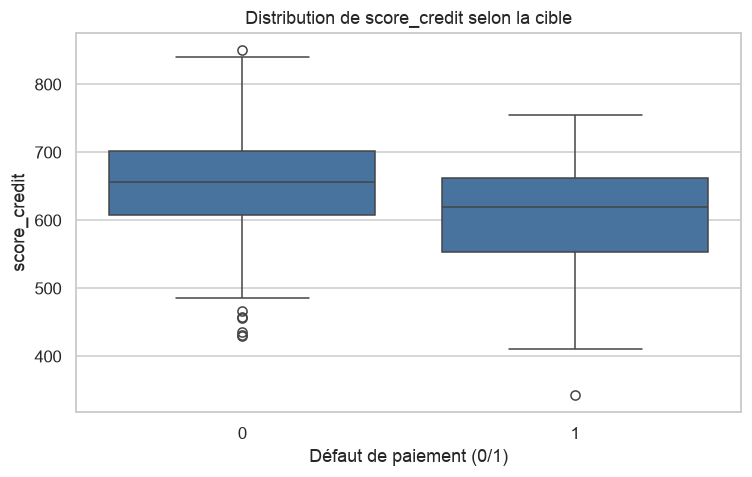

Une faible association univariée n'exclut pas une interaction. Toute suppression fondée sur y doit être apprise dans la validation croisée.


In [16]:
# Solution possible
spearman_exercice = (
    train_eda[numeric_for_corr]
    .corr(method="spearman")["defaut_paiement"]
    .drop("defaut_paiement")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(spearman_exercice.rename("Spearman avec la cible").round(3).to_frame())

top_feature = spearman_exercice.index[0]
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=train_eda, x="defaut_paiement", y=top_feature, color=BLUE)
plt.title(f"Distribution de {top_feature} selon la cible")
plt.xlabel("Défaut de paiement (0/1)")
plt.tight_layout()
plt.show()
print(
    "Une faible association univariée n'exclut pas une interaction. "
    "Toute suppression fondée sur y doit être apprise dans la validation croisée."
)

## Conclusion

Vous avez suivi la chaîne complète : nature et rôle des colonnes, audit Pandas, expressions Polars, visualisations descriptives, split, corrélations numériques, associations catégorielles, information mutuelle, sélection métier, validation croisée et test final.

À retenir :

- le type informatique ne définit pas le sens d'une variable ;
- les relations avec la cible s'explorent sur l'entraînement ;
- une corrélation faible n'exclut pas une relation non linéaire ;
- une corrélation forte ne prouve ni causalité ni licéité ;
- la sélection finale doit être validée comme une partie du pipeline.